# Global COVID-19 and Health Expenditure Analysis

This project explores country-level COVID-19 outcomes in relation to healthcare expenditure, income group, and regional differences. The analysis includes data cleaning, exploratory data analysis, visualization, and an exploratory modeling section to examine associations with deaths per million.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('covid.csv')
df

,country,date,yearly_cases,yearly_deaths,yearly_cases_per_million,yearly_deaths_per_million,Region,IncomeGroup,date_health,health_percentage_gdp
0,Afghanistan,2019,NaN,NaN,NaN,NaN,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2019,14.831320
1,Afghanistan,2020,52330.0,2189.0,1289.589606,53.944423,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2020,15.533614
2,Afghanistan,2021,105729.0,5167.0,2605.523017,127.332496,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2021,21.508461
3,Afghanistan,2022,49495.0,493.0,1219.725541,12.149201,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2022,23.088169
4,Africa,2019,NaN,NaN,NaN,NaN,NaN,NaN,2019,NaN
...,...,...,...,...,...,...,...,...,...,...
991,Zambia,2022,85003.0,293.0,4217.906216,14.538858,Sub-Saharan Africa,Lower middle income,2022,5.255923
992,Zimbabwe,2019,NaN,NaN,NaN,NaN,Sub-Saharan Africa,Lower middle income,2019,3.232678
993,Zimbabwe,2020,13625.0,360.0,847.905378,22.403371,Sub-Saharan Africa,Lower middle income,2020,2.954401
994,Zimbabwe,2021,198103.0,4637.0,12328.264156,288.567871,Sub-Saharan Africa,Lower middle income,2021,2.785717


In [4]:
# Fetch the first 5 rows of dataset
df

,country,date,yearly_cases,yearly_deaths,yearly_cases_per_million,yearly_deaths_per_million,Region,IncomeGroup,date_health,health_percentage_gdp
0,Afghanistan,2019,NaN,NaN,NaN,NaN,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2019,14.831320
1,Afghanistan,2020,52330.0,2189.0,1289.589606,53.944423,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2020,15.533614
2,Afghanistan,2021,105729.0,5167.0,2605.523017,127.332496,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2021,21.508461
3,Afghanistan,2022,49495.0,493.0,1219.725541,12.149201,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2022,23.088169
4,Africa,2019,NaN,NaN,NaN,NaN,NaN,NaN,2019,NaN
...,...,...,...,...,...,...,...,...,...,...
991,Zambia,2022,85003.0,293.0,4217.906216,14.538858,Sub-Saharan Africa,Lower middle income,2022,5.255923
992,Zimbabwe,2019,NaN,NaN,NaN,NaN,Sub-Saharan Africa,Lower middle income,2019,3.232678
993,Zimbabwe,2020,13625.0,360.0,847.905378,22.403371,Sub-Saharan Africa,Lower middle income,2020,2.954401
994,Zimbabwe,2021,198103.0,4637.0,12328.264156,288.567871,Sub-Saharan Africa,Lower middle income,2021,2.785717


In [7]:
#summarized dataset


summary_by_country = (
    df.groupby(["country", "Region", "IncomeGroup"], as_index=False)
      .agg({
          "yearly_cases": "sum",
          "yearly_deaths": "sum",
          "yearly_cases_per_million": "sum",
          "yearly_deaths_per_million": "sum",
          "health_percentage_gdp": "mean"
      })
      .rename(columns={
          "yearly_cases": "total_cases",
          "yearly_deaths": "total_deaths",
          "yearly_cases_per_million": "total_cases_per_million",
          "yearly_deaths_per_million": "total_deaths_per_million",
          "health_percentage_gdp": "avg_health_percentage_gdp"
      })
)

health = df.loc[df["date_health"].isin([2019, 2022]),
                ["country","Region","IncomeGroup","date_health","health_percentage_gdp"]].dropna(subset=["health_percentage_gdp"])
health["date_health"] = health["date_health"].astype(int)

pivot_health = (
    health.pivot_table(index=["country","Region","IncomeGroup"],
                       columns="date_health",
                       values="health_percentage_gdp",
                       aggfunc="first")
    .reset_index()
)
pivot_health.columns = [str(c) for c in pivot_health.columns]
if "2019" not in pivot_health.columns: pivot_health["2019"] = np.nan
if "2022" not in pivot_health.columns: pivot_health["2022"] = np.nan

pivot_health["expenditure_growth"] = (pivot_health["2022"] - pivot_health["2019"]) / pivot_health["2019"] * 100

summary_by_country = summary_by_country.merge(
    pivot_health[["country","Region","IncomeGroup","expenditure_growth"]],
    on=["country","Region","IncomeGroup"],
    how="left"
)

summary_by_country["health_system_performance"] = (
    summary_by_country["total_deaths"] / summary_by_country["total_cases"]
).replace([np.inf, -np.inf], np.nan)

summary_by_country = summary_by_country[
    [
        "country","Region","IncomeGroup",
        "total_cases","total_deaths",
        "total_cases_per_million","total_deaths_per_million",
        "avg_health_percentage_gdp","expenditure_growth",
        "health_system_performance"
    ]
]

summary_by_country = summary_by_country.dropna(
    subset=["expenditure_growth", "health_system_performance"]
)
df1 = summary_by_country
df1

,country,Region,IncomeGroup,total_cases,total_deaths,total_cases_per_million,total_deaths_per_million,avg_health_percentage_gdp,expenditure_growth,health_system_performance
0,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,207554.0,7849.0,5114.838164,193.426119,18.740391,55.671710,0.037817
1,Albania,Europe & Central Asia,Upper middle income,332768.0,3596.0,117687.251420,1271.766985,6.989712,-9.741280,0.010806
2,Algeria,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,271217.0,6881.0,5963.783413,151.306126,4.922432,-33.120999,0.025371
4,Andorra,Europe & Central Asia,High income,47751.0,158.0,599322.246627,1983.056166,7.995320,2.915954,0.003309
5,Angola,Sub-Saharan Africa,Lower middle income,105095.0,1930.0,2949.208564,54.160260,2.942555,18.268837,0.018364
...,...,...,...,...,...,...,...,...,...,...
177,Uruguay,Latin America & Caribbean,High income,1011988.0,7562.0,298445.557960,2230.110742,9.042981,-3.196397,0.007472
178,Uzbekistan,Europe & Central Asia,Lower middle income,167292.0,1016.0,4788.128628,29.079326,6.793216,36.420288,0.006073
179,Vanuatu,East Asia & Pacific,Lower middle income,12014.0,14.0,38381.669829,44.726434,4.077979,18.628330,0.001165
180,Zambia,Sub-Saharan Africa,Lower middle income,334196.0,4023.0,16583.031019,199.623975,6.238871,-22.172556,0.012038


In [8]:
df1.describe()  # Para columnas numéricas

,total_cases,total_deaths,total_cases_per_million,total_deaths_per_million,avg_health_percentage_gdp,expenditure_growth,health_system_performance
count,1.630000e+02,1.630000e+02,163.000000,163.000000,163.000000,163.000000,163.000000
mean,3.858001e+06,3.560803e+04,172955.074705,1295.488197,7.175748,6.116795,0.013231
std,1.216255e+07,1.156519e+05,184904.282250,1402.979866,3.151866,19.762105,0.011326
min,2.779000e+03,0.000000e+00,375.080170,0.000000,2.321040,-42.415322,0.000000
25%,5.734650e+04,6.865000e+02,12518.055079,125.798539,4.824028,-3.324942,0.005303
50%,4.010930e+05,4.230000e+03,100542.036490,814.999118,6.793216,4.802493,0.010722
75%,1.778412e+06,1.927400e+04,289332.147809,2014.559722,9.103069,13.384773,0.019362
max,9.941170e+07,1.082456e+06,680120.941701,6517.565849,19.639156,96.924169,0.078412


In [54]:
# Fetch the different type of data types
print (df1.dtypes)

country                       object
Region                        object
IncomeGroup                   object
total_cases                  float64
total_deaths                 float64
total_cases_per_million      float64
total_deaths_per_million     float64
avg_health_percentage_gdp    float64
expenditure_growth           float64
health_system_performance    float64
dtype: object


In [55]:
#Fetch summary information of the DataFrame using the info() method.
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163 entries, 0 to 181
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    163 non-null    object 
 1   Region                     163 non-null    object 
 2   IncomeGroup                163 non-null    object 
 3   total_cases                163 non-null    float64
 4   total_deaths               163 non-null    float64
 5   total_cases_per_million    163 non-null    float64
 6   total_deaths_per_million   163 non-null    float64
 7   avg_health_percentage_gdp  163 non-null    float64
 8   expenditure_growth         163 non-null    float64
 9   health_system_performance  163 non-null    float64
dtypes: float64(7), object(3)
memory usage: 14.0+ KB


In [56]:
# find the number of row and column using shape function
rows, columns = df1.shape
print(f"Number of rows are: {rows}")
print(f"Numbers of column are: {columns}")

Number of rows are: 163
Numbers of column are: 10


In [57]:
#finds the missing values in data
missing_values = df1.isnull().sum()

#Gives if there are missing value in the dataset.
if missing_values.sum() > 0:
  print("There are missing data point in the data set.")
else:
  print("There are no missing data point in the data set.")

There are no missing data point in the data set.


In [58]:
missing_columns = missing_values[missing_values > 0]
missing_columns

,0


In [59]:
df1.isnull().mean() * 100

,0
country,0.0
Region,0.0
IncomeGroup,0.0
total_cases,0.0
total_deaths,0.0
total_cases_per_million,0.0
total_deaths_per_million,0.0
avg_health_percentage_gdp,0.0
expenditure_growth,0.0
health_system_performance,0.0


In [60]:
# Code to find the full statistical summary of data
df1.describe()

,total_cases,total_deaths,total_cases_per_million,total_deaths_per_million,avg_health_percentage_gdp,expenditure_growth,health_system_performance
count,1.630000e+02,1.630000e+02,163.000000,163.000000,163.000000,163.000000,163.000000
mean,3.858001e+06,3.560803e+04,172955.074705,1295.488197,7.175748,6.116795,0.013231
std,1.216255e+07,1.156519e+05,184904.282250,1402.979866,3.151866,19.762105,0.011326
min,2.779000e+03,0.000000e+00,375.080170,0.000000,2.321040,-42.415322,0.000000
25%,5.734650e+04,6.865000e+02,12518.055079,125.798539,4.824028,-3.324942,0.005303
50%,4.010930e+05,4.230000e+03,100542.036490,814.999118,6.793216,4.802493,0.010722
75%,1.778412e+06,1.927400e+04,289332.147809,2014.559722,9.103069,13.384773,0.019362
max,9.941170e+07,1.082456e+06,680120.941701,6517.565849,19.639156,96.924169,0.078412


# Percentage of income Group

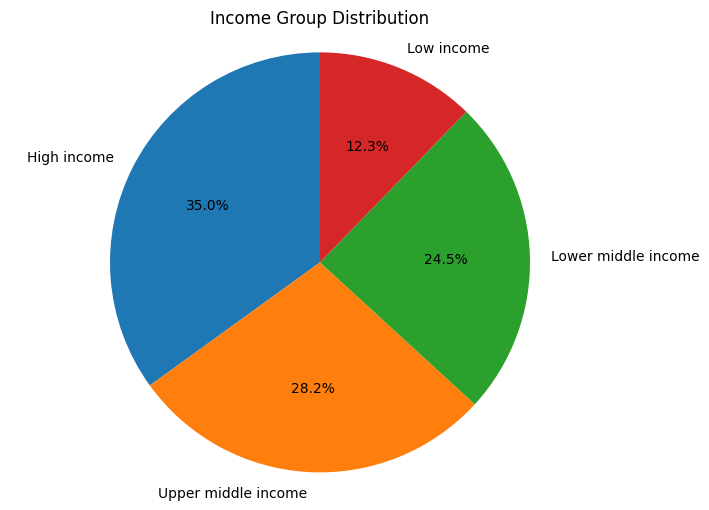

In [61]:

# Count values for each income group
income_counts = df1['IncomeGroup'].value_counts()

# Plot pie chart
plt.figure(figsize=(8,6))
plt.pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Income Group Distribution")
plt.axis('equal')  # Ensures pie chart is circular
plt.show()

Analysis:

The dataset is dominated by high income (35.0%) and upper middle income (28.2%) countries, together comprising 63.2% of entries. Lower middle income countries account for 24.5%, while low income countries form the smallest share at 12.3%.

# Count of income Group

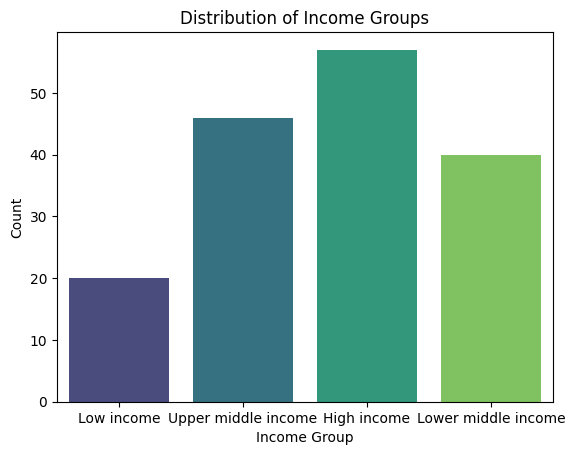

In [62]:
sns.countplot(x='IncomeGroup', data=df1, palette='viridis',  hue='IncomeGroup')
plt.title('Distribution of Income Groups')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.show()

Analysis:

The chart shows that high income countries have the highest representation (57), followed by upper middle income (46) and lower middle income (40). Low income countries are the least represented (20). This indicates a dataset skewed toward higher-income nations, which could influence any comparative socio-economic analysis.

Visual representation of income group.

# Top 5 Regions by Count

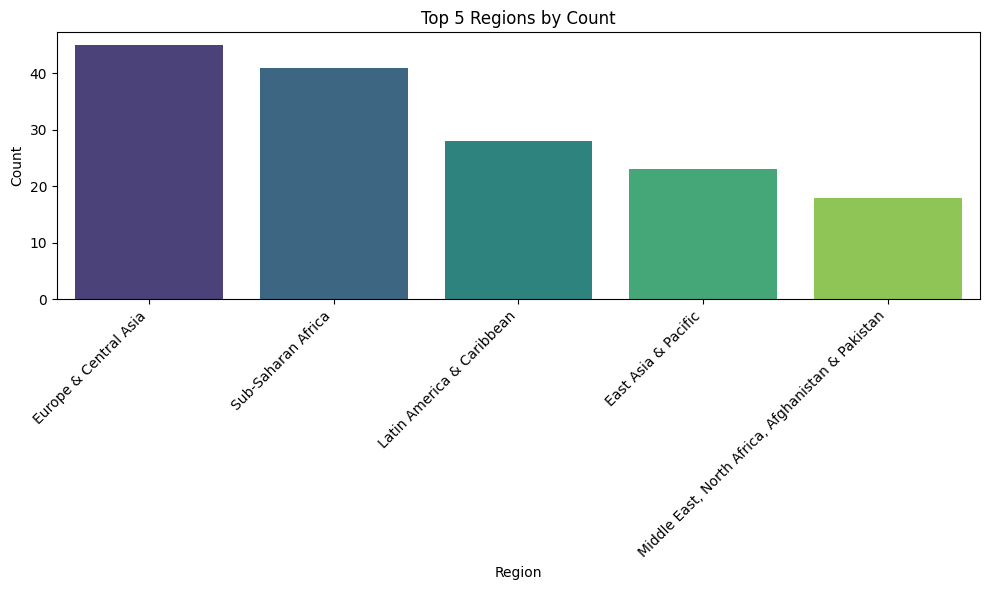

In [63]:
plt.figure(figsize=(10,6))

top_regions = df1['Region'].value_counts().head(5)
sns.barplot(
    x=top_regions.index,
    y=top_regions.values,
    hue=top_regions.index,
    palette="viridis",
    legend=False
)

plt.title("Top 5 Regions by Count")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.tight_layout()
plt.show()

The dataset is most heavily represented by Europe & Central Asia (45), followed by Sub-Saharan Africa (41). Latin America & Caribbean (28), East Asia & Pacific (23), and Middle East, North Africa, Afghanistan & Pakistan (18) have comparatively fewer entries. The strong presence of European and African regions suggests potential geographic bias in the dataset, which should be considered in any region-based analysis.

In [64]:
#find the unique Yearly cases

print(f'There are {df["yearly_cases"].nunique():,} number of Yearly cases.')

There are 710 number of Yearly cases.


# Distribution of health percentage gdp

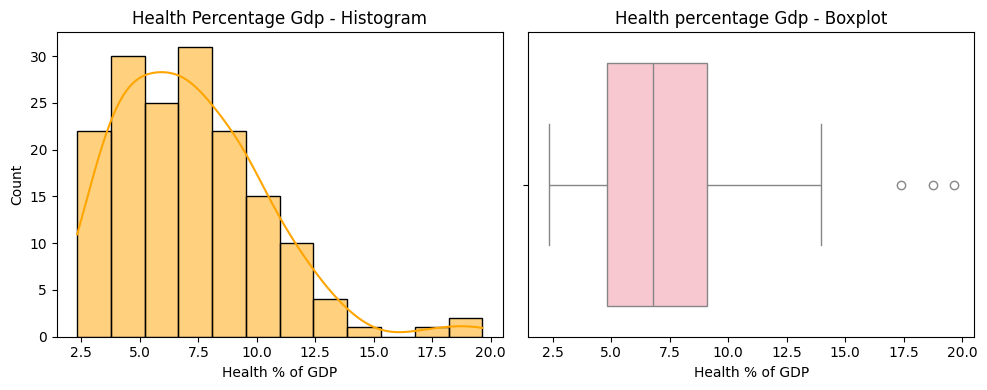

In [65]:
plt.figure(figsize=(10,4))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df1['avg_health_percentage_gdp'].dropna(), kde=True, color='orange')
plt.title("Health Percentage Gdp - Histogram")
plt.xlabel("Health % of GDP")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df1['avg_health_percentage_gdp'], color='pink')
plt.title("Health percentage Gdp - Boxplot")
plt.xlabel("Health % of GDP")

plt.tight_layout()
plt.show()

Analysis – Health % of GDP

Histogram: Most countries spend between 4% and 10% of GDP on health, with the distribution slightly right-skewed, indicating a few countries spend much higher proportions.

Boxplot: The median health expenditure is around 7% of GDP, with most countries falling within 4%–13%. There are a few outliers above 17%, representing exceptionally high health spending relative to GDP.

Insight: While the majority cluster around moderate spending levels, the presence of high-spending outliers could impact averages, making median a better central measure.

# Distribution of total deaths per million

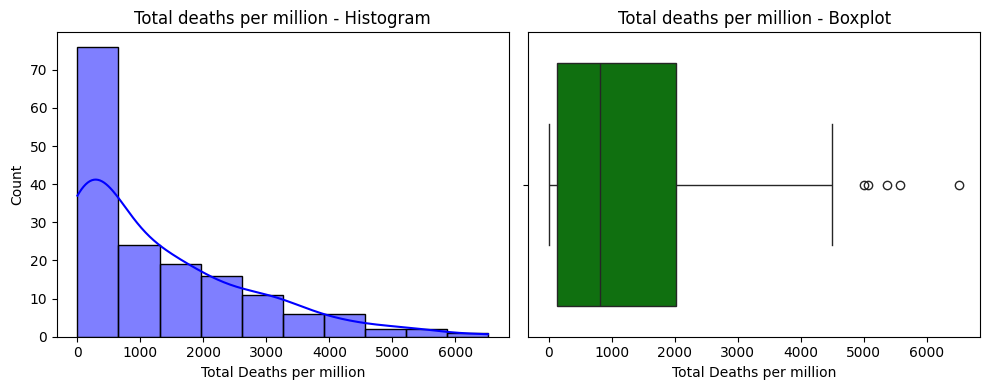

In [66]:
plt.figure(figsize=(10,4))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df1['total_deaths_per_million'].dropna(), kde=True, color='blue')
plt.title("Total deaths per million - Histogram")
plt.xlabel("Total Deaths per million")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df1['total_deaths_per_million'], color='green')
plt.title("Total deaths per million - Boxplot")
plt.xlabel("Total Deaths per million")

plt.tight_layout()
plt.show()

Analysis – Total Deaths per Million

Histogram: The data is heavily right-skewed, with most countries reporting fewer than 1,000 deaths per million.

Boxplot: The median is under 1,000, and the interquartile range (IQR) spans roughly 200 to 2,200 deaths per million.

Outliers: Several extreme outliers exceed 5,000 deaths per million, indicating that a few countries experienced disproportionately high mortality rates.

Insight: Given the skew and outliers, median and percentile-based measures are more reliable than the mean for describing central tendency.

# Distribution of total cases per million

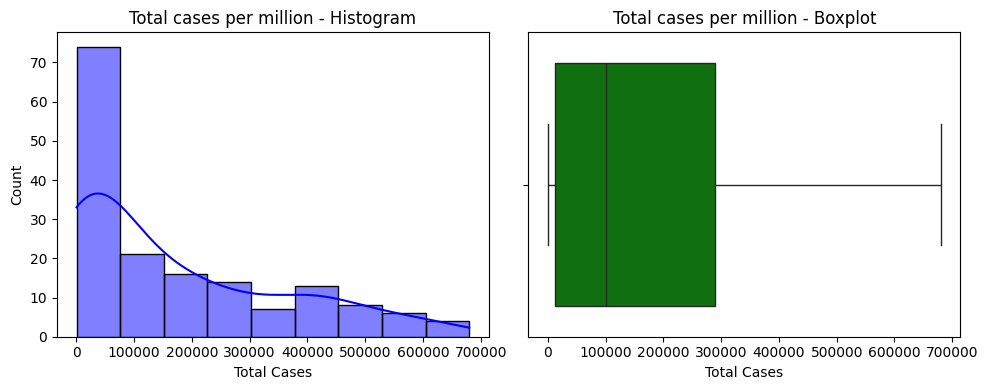

In [67]:

plt.figure(figsize=(10,4))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df1['total_cases_per_million'].dropna(), kde=True, color='blue')
plt.title("Total cases per million - Histogram")
plt.xlabel("Total Cases")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df1['total_cases_per_million'], color='green')
plt.title("Total cases per million - Boxplot")
plt.xlabel("Total Cases")

plt.tight_layout()
plt.show()

 Analysis – Total Cases per Million

Histogram: The distribution is right-skewed, with most countries reporting fewer than 100,000 cases per million, but a notable tail of countries reaching up to nearly 700,000 cases per million.

Boxplot: The median lies below 150,000 cases per million, with a wide spread and no extreme outliers beyond the whiskers (values above ~700,000 are at the upper end).

Insight: While the majority of countries have relatively moderate case rates, a few with exceptionally high case counts significantly stretch the range, highlighting large disparities in reported COVID-19 impact.

# Bivariant Analysis

Relationship between Health percentage GDP vs IncomeGroup

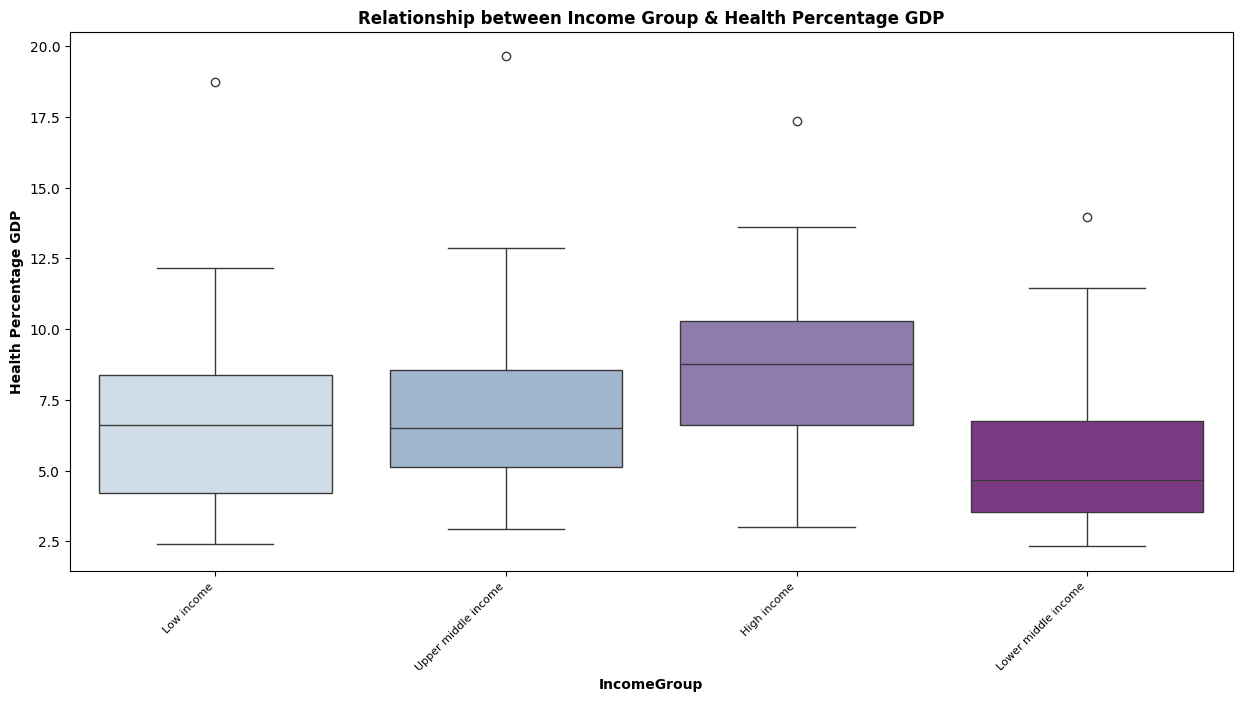

In [68]:
# Examine the relationship between day of the week and delivery time.
plt.figure(figsize=(15,7))

# Create a boxplot to show the relationship between day of the week and delivery time.
sns.boxplot(x = 'IncomeGroup', y = 'avg_health_percentage_gdp', data = df1, palette = 'BuPu', hue ='IncomeGroup')

# Set the labels, title, position, fontsize and alignment for the bar chart output.
plt.xlabel('IncomeGroup', fontsize=10, fontweight='bold')
plt.ylabel('Health Percentage GDP', fontsize=10, fontweight='bold')
plt.title('Relationship between Income Group & Health Percentage GDP', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, fontsize=8, horizontalalignment='right')
plt.xticks(rotation = 45)

# Show the plot.
plt.show()

Analysis – Income Group vs Health % of GDP

High income countries generally spend the highest share of GDP on health, with a median near 9%, and a wider spread toward higher values.

Low income and upper middle income countries have similar medians (~6–7%), though low income countries show slightly more variability and a few high outliers.

Lower middle income countries spend the least, with a median below 5% and a relatively narrow range.

Insight: Economic capacity appears linked to health spending, but variability and outliers show that income group alone doesn’t fully explain differences in GDP allocation to health.

**Relationship between Total Cases and Total Deaths**

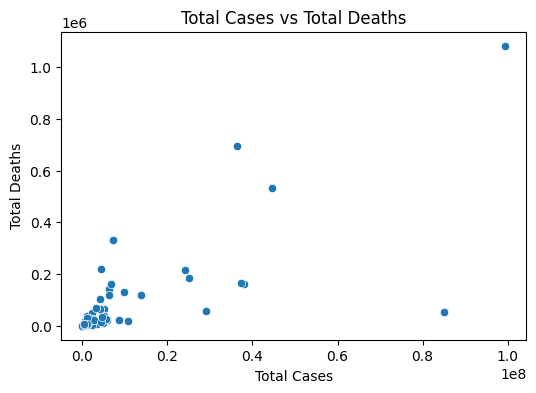

In [69]:
# Scatter plot: yearly_cases vs yearly_deaths
plt.figure(figsize=(6,4))
sns.scatterplot(data=df1, x='total_cases', y='total_deaths')

# Add title and axis labels
plt.title("Total Cases vs Total Deaths")
plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")

plt.show()

 Analysis – Total Cases vs Total Deaths

There is a positive relationship between total cases and total deaths — countries with more cases generally report more deaths.

A majority of countries cluster at the lower end for both cases and deaths, while a few countries are extreme outliers with very high totals.

The wide spread among high-case countries suggests that mortality rates vary significantly, likely influenced by healthcare capacity, demographics, and reporting accuracy.

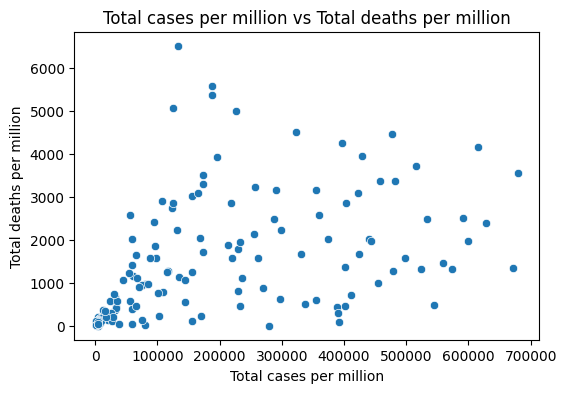

In [70]:
# Scatter plot: total_cases_per_million vs yearly_deaths_per_million
plt.figure(figsize=(6,4))
sns.scatterplot(data=df1, x='total_cases_per_million', y='total_deaths_per_million')

# Add title and axis labels
plt.title("Total cases per million vs Total deaths per million")
plt.xlabel("Total cases per million")
plt.ylabel("Total deaths per million")
plt.show()

Analysis – Total Cases per Million vs Total Deaths per Million

There is a positive correlation: countries with higher cases per million generally have higher deaths per million.

The spread indicates variation in case-fatality rates — some countries with high case rates have relatively lower death rates, possibly due to better healthcare systems or more effective interventions.

A dense cluster exists at lower values, while a few points show extreme mortality relative to population size, marking them as potential outliers for deeper investigation.

# Heatmap for correlation

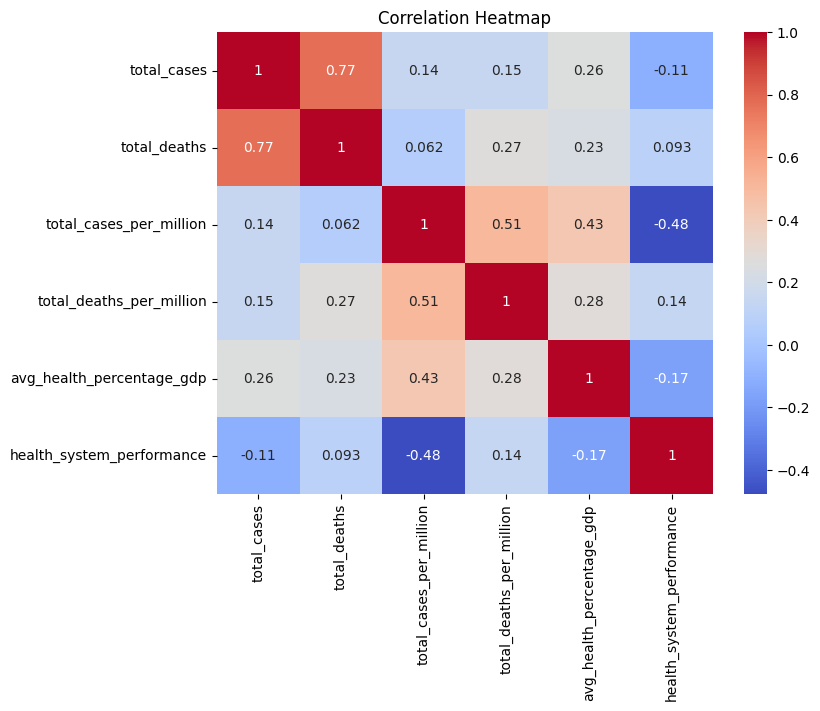

In [91]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(df1[['total_cases','total_deaths','total_cases_per_million',
                'total_deaths_per_million','avg_health_percentage_gdp','health_system_performance']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Analysis – Correlation Heatmap

1. Strong Positive Correlation:

total_cases and total_deaths (0.77) — more cases are associated with more deaths.

total_cases_per_million and total_deaths_per_million (0.51) — higher case rates per population link to higher death rates per population.

2. Moderate Positive Correlation:

avg_health_percentage_gdp with total_cases_per_million (0.43) — countries spending more on health tend to report more cases per million, possibly due to better detection and reporting.

3. Notable Negative Correlation:

health_system_performance with total_cases_per_million (-0.48) — better health systems are linked with fewer cases per population.

Insight: While case and death counts are strongly related, healthcare system quality appears to play a protective role in reducing case rates.

# Correlation between Income Group and Health system Performance

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


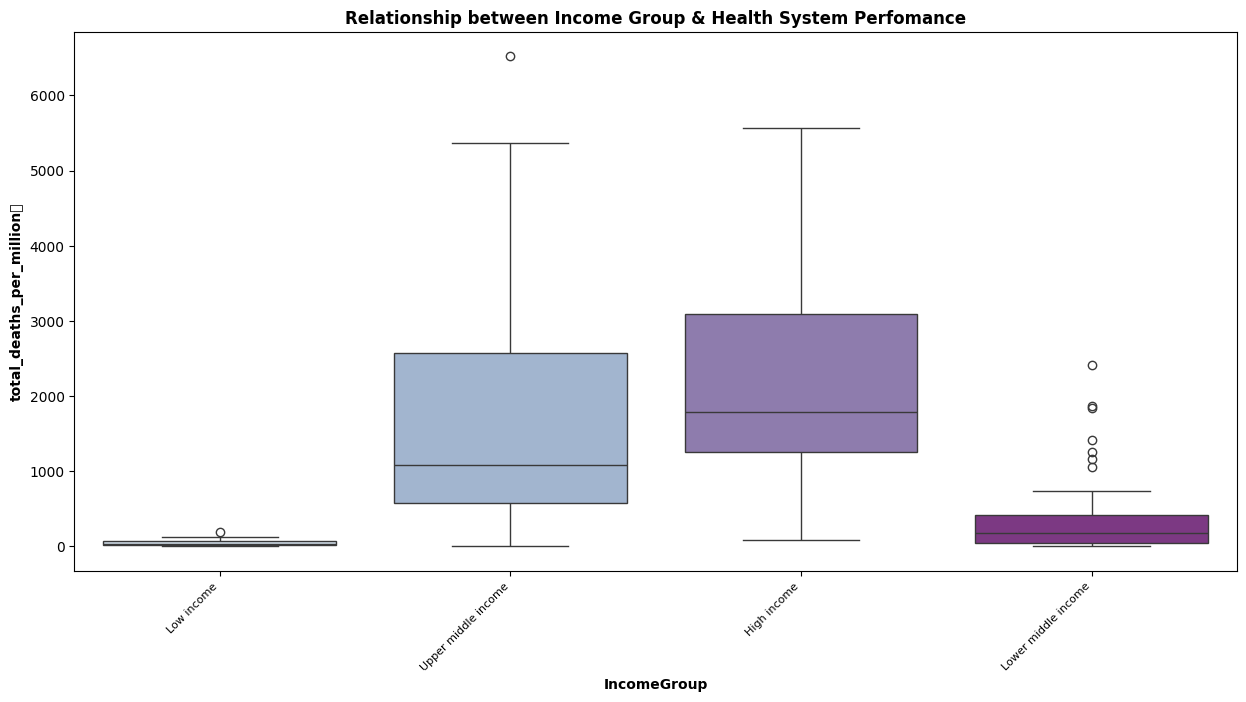

In [10]:
# Examine the relationship between day of the week and delivery time.
plt.figure(figsize=(15,7))

# Create a boxplot to show the relationship between day of the week and delivery time.
sns.boxplot(x = 'IncomeGroup', y = 'total_deaths_per_million', data = df1, palette = 'BuPu', hue ='IncomeGroup')

# Set the labels, title, position, fontsize and alignment for the bar chart output.
plt.xlabel('IncomeGroup', fontsize=10, fontweight='bold')
plt.ylabel('total_deaths_per_million	', fontsize=10, fontweight='bold')
plt.title('Relationship between Income Group & Health System Perfomance', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, fontsize=8, horizontalalignment='right')
plt.xticks(rotation = 45)

# Show the plot.
plt.show()

Analysis – Income Group vs Health System Performance

Median performance is highest for low income countries (~0.02) and lowest for high income countries (~0.005), which may indicate differences in how performance is measured (possibly efficiency rather than resources).

Upper middle and lower middle income groups fall in between, with median values around 0.01–0.02.

Variability: Low income countries show the widest range and most extreme outliers, while high income countries have a narrower distribution but several low-end outliers.

Insight: The measure of “health system performance” here does not directly align with wealth — lower-income groups sometimes perform relatively well, suggesting efficiency factors may outweigh spending levels.

# Relationship between Total deaths per million vs Health % GDP

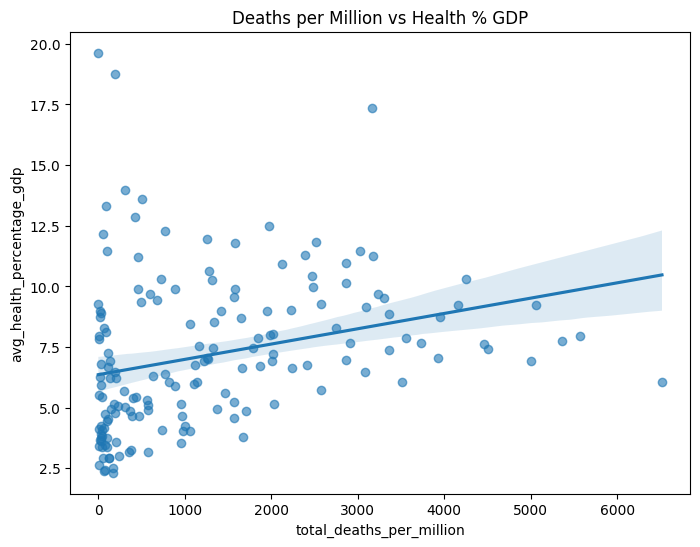

In [96]:
# 4. Scatter with regression: Cases per million vs Health % GDP
plt.figure(figsize=(8,6))
sns.regplot(data=df1, x='total_deaths_per_million', y='avg_health_percentage_gdp', scatter_kws={'alpha':0.6})
plt.title("Deaths per Million vs Health % GDP")
plt.show()



Analysis – Deaths per Million vs Health % GDP

The scatter plot with regression line shows a slight positive correlation — higher death rates per million are somewhat associated with higher health spending as a share of GDP.

This counterintuitive trend may indicate that countries hit hardest by deaths tend to invest more in health (either pre-existing high spending or increased spending during crises).

The spread is wide, suggesting that many high-spending countries still have low death rates, and vice versa.

Insight: Health expenditure alone doesn’t fully explain mortality rates — other factors like healthcare quality, pandemic management, and population demographics likely play a major role.

# Top 10 countries overall by deaths per million

/tmp/ipython-input-1984964120.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


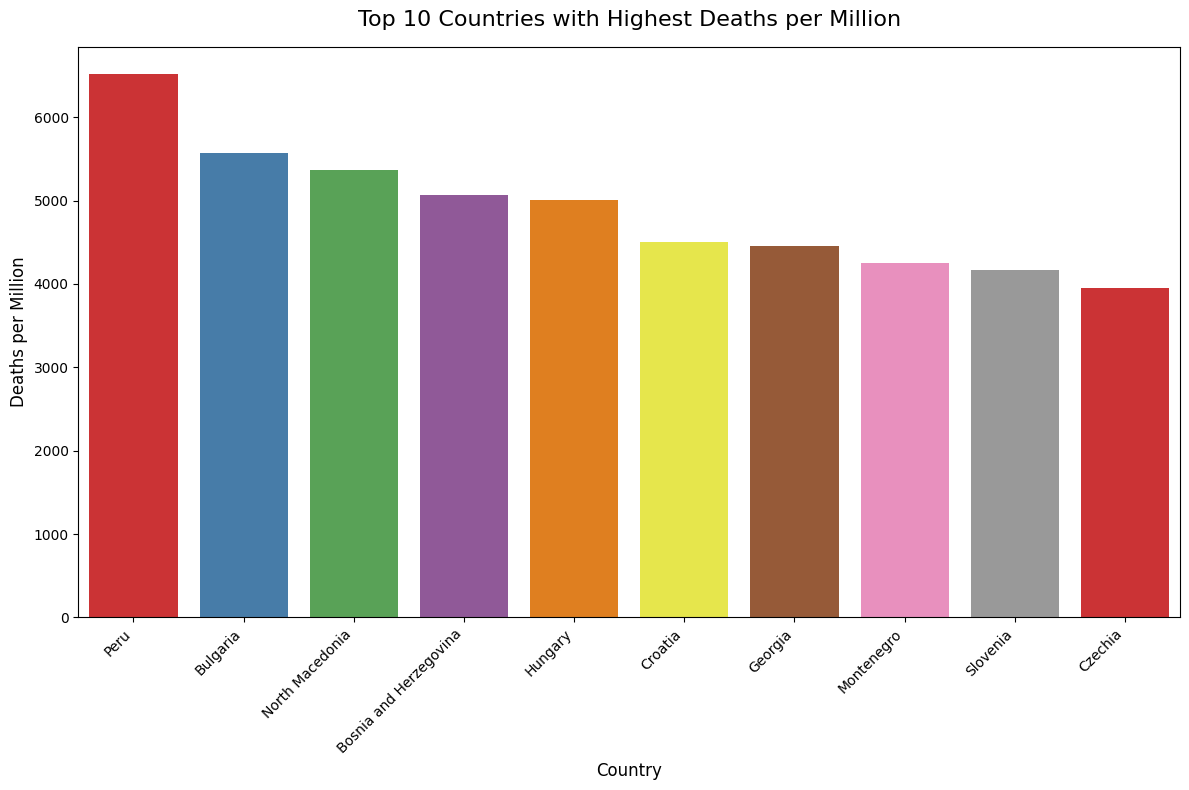

In [94]:
# Select top 10 countries overall by deaths per million
top10_countries = (
    df1.sort_values('total_deaths_per_million', ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(12,8))
sns.barplot(
    data=top10_countries,
    x='country',
    y='total_deaths_per_million',
    palette='Set1',
     ci=None, errorbar=None,
    hue = 'country'
)

plt.title("Top 10 Countries with Highest Deaths per Million", fontsize=16, pad=15)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Deaths per Million", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 Analysis – Top 10 Countries with Highest Deaths per Million

Peru has the highest deaths per million (~6,500), standing out significantly from others.

Bulgaria, North Macedonia, Bosnia and Herzegovina, and Hungary follow, each exceeding 5,000 deaths per million.

The remaining countries — Croatia, Georgia, Montenegro, Slovenia, and Czechia — report between 4,000 and 4,600 deaths per million.

Insight: Many of these countries are in Eastern Europe, indicating potential regional patterns possibly linked to healthcare capacity, demographic factors, or pandemic response strategies.

### MODEL BUILDING

In [75]:
#getting the info of the dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163 entries, 0 to 181
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    163 non-null    object 
 1   Region                     163 non-null    object 
 2   IncomeGroup                163 non-null    object 
 3   total_cases                163 non-null    float64
 4   total_deaths               163 non-null    float64
 5   total_cases_per_million    163 non-null    float64
 6   total_deaths_per_million   163 non-null    float64
 7   avg_health_percentage_gdp  163 non-null    float64
 8   expenditure_growth         163 non-null    float64
 9   health_system_performance  163 non-null    float64
dtypes: float64(7), object(3)
memory usage: 14.0+ KB


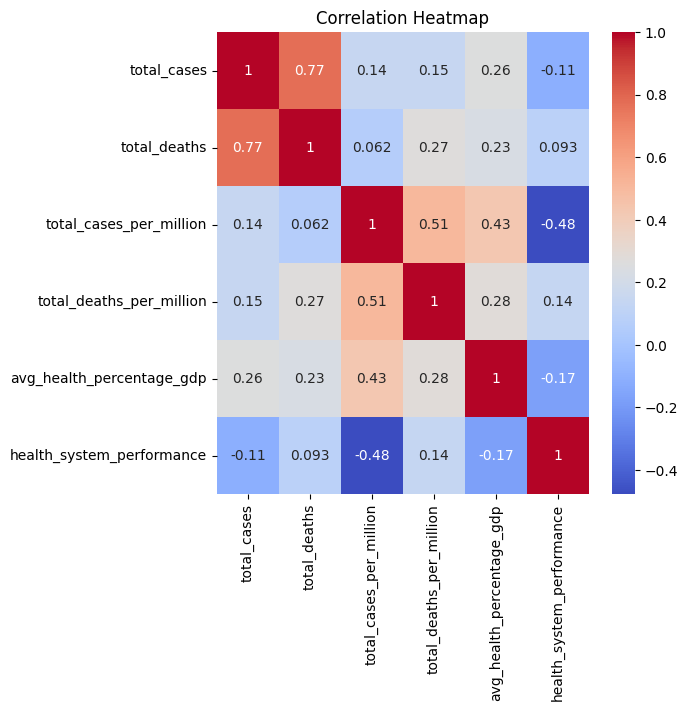

In [76]:
#plotting the correlation heatmap of the dataset
# Correlation heatmap for numeric columns
plt.figure(figsize=(6,6))
sns.heatmap(df1[['total_cases','total_deaths','total_cases_per_million',
                'total_deaths_per_million','avg_health_percentage_gdp','health_system_performance']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

 Analysis – Correlation Heatmap

1. Strongest Positive Correlation:

    total_cases ↔ total_deaths (0.77) — higher case counts strongly align with higher death counts.

    total_cases_per_million ↔ total_deaths_per_million (0.51) — higher case rates per million lead to higher death rates per million.

2. Moderate Positive Correlation:

    avg_health_percentage_gdp ↔ total_cases_per_million (0.43) — higher health spending is linked to higher reported cases, possibly due to better detection/reporting.

3. Notable Negative Correlation:

    health_system_performance ↔ total_cases_per_million (-0.48) — better health systems tend to have lower case rates per population.

    Insight: While case and death metrics are closely tied, health system performance shows a protective effect, and high health spending may reflect stronger reporting rather than worse health outcomes.

#### to predict the total_deaths_per_million, we can get rid of the total_deaths and the total_cases
#### also the Income Group needs to be encoded, the region column can be eliminated as well

In [77]:
df2=df1.copy()
df2.columns

Index(['country', 'Region', 'IncomeGroup', 'total_cases', 'total_deaths',
       'total_cases_per_million', 'total_deaths_per_million',
       'avg_health_percentage_gdp', 'expenditure_growth',
       'health_system_performance'],
      dtype='object')

In [78]:
#dropping the cols
df2=df2.drop(columns=['Region','total_cases','total_deaths'])

In [79]:
df2.columns

Index(['country', 'IncomeGroup', 'total_cases_per_million',
       'total_deaths_per_million', 'avg_health_percentage_gdp',
       'expenditure_growth', 'health_system_performance'],
      dtype='object')

In [80]:
df2['IncomeGroup'].value_counts()

,count
IncomeGroup,
High income,57
Upper middle income,46
Lower middle income,40
Low income,20


In [81]:
#performing ordinal encoding on IncomeGroup
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['Low income', 'Lower middle income', 'Upper middle income', 'High income']])
df2['income_group_encoded'] = encoder.fit_transform(df2[['IncomeGroup']])

In [82]:
df2.columns

Index(['country', 'IncomeGroup', 'total_cases_per_million',
       'total_deaths_per_million', 'avg_health_percentage_gdp',
       'expenditure_growth', 'health_system_performance',
       'income_group_encoded'],
      dtype='object')

In [83]:
df2=df2.drop(columns=['IncomeGroup'])

In [84]:
df2.columns

Index(['country', 'total_cases_per_million', 'total_deaths_per_million',
       'avg_health_percentage_gdp', 'expenditure_growth',
       'health_system_performance', 'income_group_encoded'],
      dtype='object')

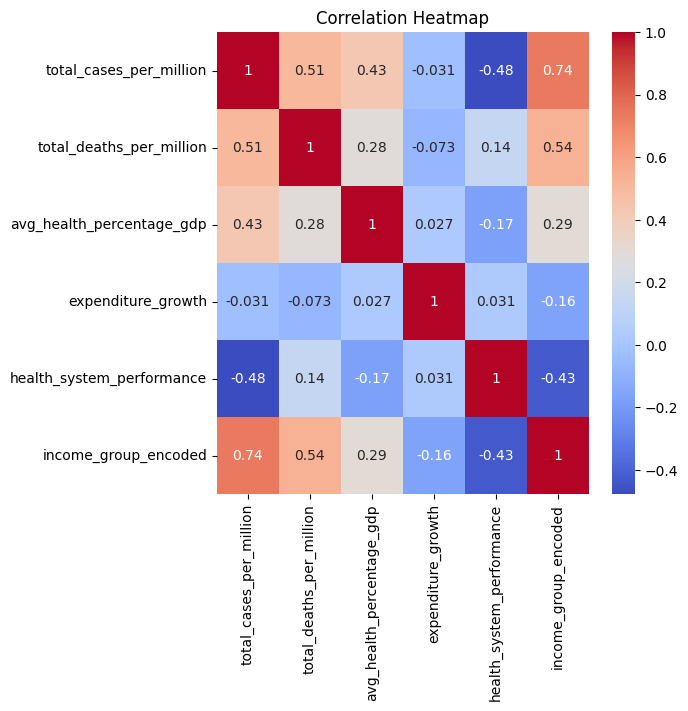

In [85]:
#plotting a correlation heatmap of the variables
# Correlation heatmap for numeric columns
plt.figure(figsize=(6,6))
sns.heatmap(df2[['total_cases_per_million','total_deaths_per_million',
                 'avg_health_percentage_gdp','expenditure_growth','health_system_performance','income_group_encoded']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### the correlation of total_cases_per_million, avg_health_expenditure_gdp, expenditure_growth,
#### health_system_performance, income_group_encoded wrt total_deaths_per_million are 0.51, 0.28, -0.073, 0.14, 0.54 resp

In [86]:
#162 countries
len(df2['country'].unique())

163

### 1. Multiple Regression Model

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import pandas as pd

# Features and target
X = df2[['country', 'total_cases_per_million', 'avg_health_percentage_gdp',
         'expenditure_growth', 'health_system_performance', 'income_group_encoded']]
y = df2['total_deaths_per_million']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing: One-hot encode 'country', leave others as is
categorical_cols = ['country']
numeric_cols = ['total_cases_per_million', 'avg_health_percentage_gdp',
                'expenditure_growth', 'health_system_performance', 'income_group_encoded']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ])

# Define model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

Test MSE: 844907.0850433862
Test RMSE: 919.1882750793693
R²: 0.4544443271271664


In [88]:
# Get feature names after one-hot encoding
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
encoded_countries = ohe.get_feature_names_out(['country'])
numeric_features = numeric_cols
all_features = list(encoded_countries) + numeric_features

# Get coefficients
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': model.named_steps['regressor'].coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)

                            Feature  Coefficient
134            income_group_encoded   573.861731
97                     country_Peru   107.104296
17                 country_Bulgaria    82.279033
90          country_North Macedonia    78.807217
14   country_Bosnia and Herzegovina    76.186594
..                              ...          ...
92                     country_Oman    -0.866295
113               country_Sri Lanka     0.333785
40                     country_Fiji    -0.191703
9                country_Azerbaijan     0.009839
130         total_cases_per_million     0.001404

[135 rows x 2 columns]


#### 2. Random Forest Regressor

In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define X and y
X = df2[['country', 'total_cases_per_million',
         'avg_health_percentage_gdp', 'expenditure_growth',
         'health_system_performance', 'income_group_encoded']]
y = df2['total_deaths_per_million']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing: One-hot encode 'country'
categorical_features = ['country']
numeric_features = ['total_cases_per_million',
                    'avg_health_percentage_gdp',
                    'expenditure_growth',
                    'health_system_performance',
                    'income_group_encoded']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Pipeline: preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

# Train model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

# Feature importance
feature_names = (
    pipeline.named_steps['preprocessor']
    .transformers_[0][1]  # OneHotEncoder
    .get_feature_names_out(categorical_features)
).tolist() + numeric_features

importances = pipeline.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(15))

RMSE: 327.85
R²: 0.931
                            Feature  Importance
130         total_cases_per_million    0.518434
133       health_system_performance    0.395703
132              expenditure_growth    0.036914
131       avg_health_percentage_gdp    0.020805
97                     country_Peru    0.006117
77                   country_Mexico    0.002007
134            income_group_encoded    0.001889
43                  country_Georgia    0.001197
14   country_Bosnia and Herzegovina    0.001108
17                 country_Bulgaria    0.001050
105              country_San Marino    0.000999
51                  country_Hungary    0.000772
57                    country_Italy    0.000685
44                   country_Greece    0.000684
34                  country_Ecuador    0.000600


In [90]:
#getting the predictions for the dataset
pred_df = X_test.copy()
pred_df['total_deaths_per_million'] = y_test
pred_df['predicted_total_deaths_per_million'] = y_pred
pred_df.head()

,country,total_cases_per_million,avg_health_percentage_gdp,expenditure_growth,health_system_performance,income_group_encoded,total_deaths_per_million,predicted_total_deaths_per_million
151,Slovenia,614983.377333,9.251070,13.126381,0.006766,3.0,4160.867329,3156.288093
130,Pakistan,6465.519152,2.923650,2.000832,0.019443,1.0,125.707520,127.527616
146,Serbia,360096.755023,9.258221,11.446510,0.007162,2.0,2579.083551,2515.011006
62,Germany,442902.005676,12.478255,7.589492,0.004450,3.0,1971.049320,2369.217311
108,Mauritius,228974.785965,6.057761,2.260460,0.003559,2.0,814.999118,923.058095
